In [47]:
# CPU
import numpy as np
import time

def matmul_cpu(A, B):
    start = time.time()
    C = np.dot(A, B)
    end = time.time()
    return C, end - start

In [48]:
import cupy as cp
import numpy as np
import time

def matmul_gpu(A, B):
    # Конвертируем в float32 если нужно
    A = A.astype(np.float32)
    B = B.astype(np.float32)
    
    # Переносим на GPU
    A_device = cp.asarray(A)
    B_device = cp.asarray(B)
    
    # Синхронизация для точного замера времени
    cp.cuda.Stream.null.synchronize()
    start = time.time()
    
    # Перемножение матриц (использует cuBLAS)
    C_device = cp.dot(A_device, B_device)
    
    # Синхронизация после вычислений
    cp.cuda.Stream.null.synchronize()
    end = time.time()
    
    # Возвращаем результат на CPU
    C = cp.asnumpy(C_device)
    
    return C, end - start

In [49]:

def generate_matrix(n):
    return np.random.rand(n, n).astype(np.float32)


def check_correctness(C_cpu, C_gpu, eps=1e-3):
    return np.allclose(C_cpu, C_gpu, atol=eps)

--------------------------------------------------
Matrix Size    CPU (sec)      GPU (sec)      Speedup        
--------------------------------------------------
100            0.000000       0.000997       0.00           
200            0.000000       0.000000       0.00           
300            0.000000       0.039138       0.00           
400            0.032882       0.006235       5.27           
500            0.003001       0.001995       1.50           
600            0.008296       0.006526       1.27           
700            0.001001       0.010518       0.10           
800            0.005100       0.014084       0.36           
900            0.009563       0.016969       0.56           
1000           0.004623       0.017674       0.26           
1100           0.011684       0.024661       0.47           
1200           0.022457       0.087003       0.26           
1300           0.026117       0.003130       8.34           
1400           0.034942       0.000000      

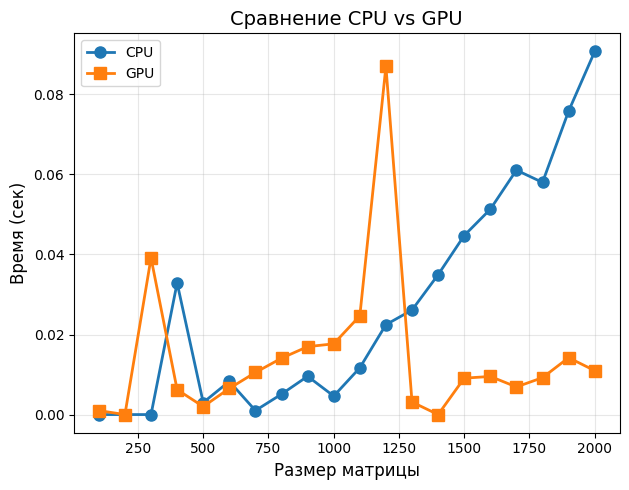

In [51]:
import matplotlib.pyplot as plt

sizes = list(range(100, 2001, 100))

cpu_times = []
gpu_times = []
speedups = []

print("-" * 50)
print(f"{'Matrix Size':<15}{'CPU (sec)':<15}{'GPU (sec)':<15}{'Speedup':<15}")
print("-" * 50)

for n in sizes:
    A = generate_matrix(n)
    B = generate_matrix(n)

    C_cpu, t_cpu = matmul_cpu(A, B)
    C_gpu, t_gpu = matmul_gpu(A, B)

    correct = check_correctness(C_cpu, C_gpu)
    
    # Вычисление ускорения
    speedup = t_cpu / t_gpu if t_gpu > 0 else 0

    cpu_times.append(t_cpu)
    gpu_times.append(t_gpu)
    speedups.append(speedup)

    # Добавил индикатор корректности в вывод
    print(f"{n:<15}{t_cpu:<15.6f}{t_gpu:<15.6f}{speedup:<15.2f}")

print("-" * 50)

# Вывод среднего ускорения
avg_speedup = sum(speedups) / len(speedups)
print(f"\nСреднее ускорение: {avg_speedup:.2f}x")
print(f"Максимальное ускорение: {max(speedups):.2f}x")
print(f"Минимальное ускорение: {min(speedups):.2f}x")

# Графики
plt.figure(figsize=(12, 5))

# График времени
plt.subplot(1, 2, 1)
plt.plot(sizes, cpu_times, marker='o', label='CPU', linewidth=2, markersize=8)
plt.plot(sizes, gpu_times, marker='s', label='GPU', linewidth=2, markersize=8)
plt.xlabel("Размер матрицы", fontsize=12)
plt.ylabel("Время (сек)", fontsize=12)
plt.title("Сравнение CPU vs GPU", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cpu_vs_gpu.png", dpi=300, bbox_inches='tight')
plt.show()